# Setup

In [1]:
!pip install -q google-adk[a2a]

In [2]:
from IPython.display import HTML, Markdown, display

In [3]:
# For google colab only
# from google.colab import userdata
# api_key = userdata.get('GOOGLE_API_KEY')

# For Local system
import os
from dotenv import load_dotenv

load_dotenv()  # This loads the variables from .env
api_key = os.getenv("GOOGLE_API_KEY")

In [4]:
import os
from google import genai
from google.genai import types
from google.adk.agents import LlmAgent
from google.adk.models.google_llm import Gemini
from google.adk.runners import InMemoryRunner, Runner
from google.adk.sessions import InMemorySessionService
from google.adk.tools import google_search, AgentTool, ToolContext
from google.adk.code_executors import BuiltInCodeExecutor

In [5]:
def show_python_code_and_result(response):
  # Helper function that prints the generated Python code and results from the code execution tool
  for i in range(len(response)):
    # Check if the response contains a valid function call result from the code executor
    if (
        (response[i].content.parts)
        and (response[i].content.parts[0])
        and (response[i].content.parts[0].function_response)
        and (response[i].content.parts[0].function_response.response)
    ):
      response_code = response[i].content.parts[0].function_response.response
      if "result" in response_code and response_code["result"] != "```":
        if "tool_code" in response_code["result"]:
          print(
              "Generated Python Code >> ",
              response_code["result"].replace("tool_code", ""),
          )
        else:
          print("Generated Python Response >> ", response_code["result"])

In [6]:
retry_config = types.HttpRetryOptions(
    attempts=5,  # Maximum retry attempts
    exp_base=7,  # Delay multiplier
    initial_delay=1,
    http_status_codes=[429, 500, 503, 504],  # Retry on these HTTP errors
)

In [7]:
# Set API key as environment variable
# os.environ['GOOGLE_API_KEY'] = userdata.get('GOOGLE_API_KEY')

client = genai.Client(api_key=api_key)

for model in client.models.list():
  print(model.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/gemma-3n-e2b-it
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
models/gemini-robotics-er-1.6-preview
models/gem

In [8]:
# Define helper functions that will be reused throughout the notebook
async def run_session(
    runner_instance: Runner,
    user_queries: list[str] | str = None,
    session_name: str = "default",
):
    print(f"\n ### Session: {session_name}")

    # Get app name from the Runner
    app_name = runner_instance.app_name

    # Attempt to create a new session or retrieve an existing one
    try:
        session = await session_service.create_session(
            app_name=app_name, user_id=USER_ID, session_id=session_name
        )
    except:
        session = await session_service.get_session(
            app_name=app_name, user_id=USER_ID, session_id=session_name
        )

    # Process queries if provided
    if user_queries:
        # Convert single query to list for uniform processing
        if type(user_queries) == str:
            user_queries = [user_queries]

        # Process each query in the list sequentially
        for query in user_queries:
            print(f"\nUser > {query}")

            # Convert the query string to the ADK Content format
            query = types.Content(role="user", parts=[types.Part(text=query)])

            # Stream the agent's response asynchronously
            async for event in runner_instance.run_async(
                user_id=USER_ID, session_id=session.id, new_message=query
            ):
                # Check if the event contains valid content
                if event.content and event.content.parts:
                    # Filter out empty or "None" responses before printing
                    if (
                        event.content.parts[0].text != "None"
                        and event.content.parts[0].text
                    ):
                        print(f"{MODEL_NAME} > ", event.content.parts[0].text)
    else:
        print("No queries!")


print("Helper functions defined.")

Helper functions defined.


# 1) Agent to Agent Communication

**The Problem**

As you build more complex AI systems, you'll find that:

- `A single agent can't do everything` - Specialized agents for different domains work better
- `You need agents to collaborate` - Customer support needs product data, order systems need inventory info
- `Different teams build different agents` - You want to integrate agents from external vendors
- `Agents may use different languages/frameworks` - You need a standard communication protocol

**The Solution**: 
```
A2A Protocol
```
The Agent2Agent (A2A) Protocol is a *standard* that allows agents to:

- Communicate over networks - Agents can be on different machines
- Use each other's capabilities - One agent can call another agent like a tool
- Work across frameworks - Language/framework agnostic
- Maintain formal contracts - Agent cards describe capabilities

**Common A2A Architecture Patterns**
The A2A protocol is particularly useful in three scenarios:

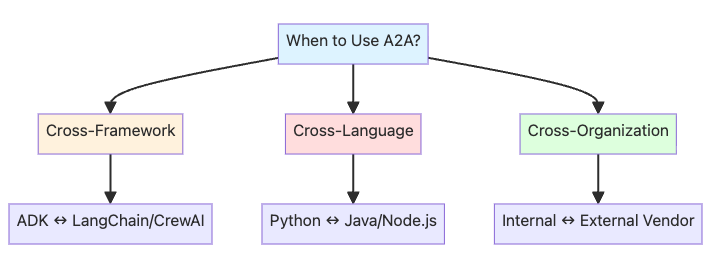

1. **Cross-Framework Integration**: ADK agent communicating with other agent frameworks
2. **Cross-Language Communication**: Python agent calling Java or Node.js agent
3. **Cross-Organization Boundaries**: Your internal agent integrating with external vendor services

## 1.1) High Level System Architecture of Agent

**We'll build a practical e-commerce integration**:

1. **Product Catalog Agent** (exposed via A2A) - External vendor service that provides product information
2. **Customer Support Agent** (consumer) - Your internal agent that helps customers by querying product data
<br>

```
┌──────────────────────┐           ┌──────────────────────┐
│ Customer Support     │  ─A2A──▶ │  Product Catalog     │
│ Agent (Consumer)     │           │ Agent (Vendor)       │
│ Your Company         │           │ External Service     │
│ (localhost:8000)     │           │ (localhost:8001)     │
└──────────────────────┘           └──────────────────────┘
```
<br>

Why this justifies A2A:

- Product Catalog is maintained by an external vendor (you can't modify their code)
- Different organizations with separate systems
- Formal contract needed between services
- Product Catalog could be in a different language/framework
<br>

**A2A vs Local Sub-Agents: Decision Table**

 Factor | Use A2A | Use Local Sub-Agents |
| :--- | :--- | :--- |
| **Agent Location** | External service, different codebase | Same codebase, internal |
| **Ownership** | Different team/organization | Your team |
| **Network** | Agents on different machines | Same process/machine |
| **Performance** | Network latency acceptable | Need low latency |
| **Language/Framework** | Cross-language/framework needed | Same language |
| **Contract** | Formal API contract required | Internal interface |
| **Example** | External vendor product catalog | Internal order processing steps |

<br>

We'll simulate both agents locally (both running on localhost) for learning purposes. In production:
- Product Catalog Agent would run on vendor's infrastructure (e.g., `https://vendor.com`)
- Customer Support Agent would run on your infrastructure
- They'd communicate over the internet using A2A protocol

This local simulation lets you learn A2A without needing to deploy services!

**`Agent Architecture Design`**

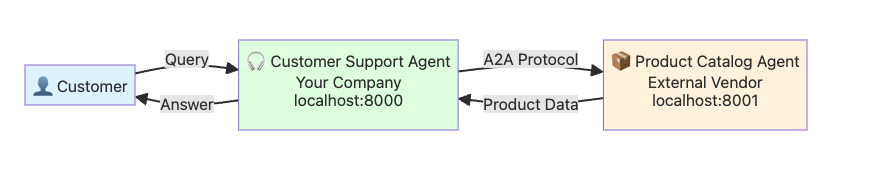

How it works
1. **Customer** asks a product question to your Customer Support Agent
2. **Support Agent** realizes it needs product information
3. **Support Agent** calls the **Product Catalog Agent** via A2A protocol
4. **Product Catalog Agent** (external vendor) returns product data
5. **Support Agent** formulates an answer and responds to the customer

---

We need to accomplish the following tasks:
1. **Create the Product Catalog Agent** - Build the vendor's agent with product lookup
2. **Expose via A2A** - Make it accessible using `to_a2a()`
3. **Start the Server** - Run the agent as a background service
4. **Create the Customer Support Agent** - Build the consumer agent
5. **Test Communication** - See A2A in action with real queries
6. **Understand the Flow** - Learn what happened behind the scenes

In [9]:
# Importing Libraries
import json
import requests
import subprocess
import time
import uuid

from google.adk.agents import LlmAgent
from google.adk.agents.remote_a2a_agent import (
    RemoteA2aAgent,
    AGENT_CARD_WELL_KNOWN_PATH,
)

from google.adk.a2a.utils.agent_to_a2a import to_a2a
from google.adk.models.google_llm import Gemini
from google.adk.runners import Runner
from google.adk.sessions import InMemorySessionService
from google.genai import types

# Hide additional warnings in the notebook
import warnings

warnings.filterwarnings("ignore")

## 1.2) Creating the Product Catalog Agent

We'll create a **Product Catalog Agent** that provides product information from an external vendor's catalog. This agent will be `exposed via A2A` so other agents (like customer support) can use it.

*Why expose this agent?*
- In a real system, this would be maintained by an **external vendor** or third-party provider
- Your internal agents (customer support, sales, inventory) need product data
- The vendor **controls their own codebase** - you can't modify their implementation
- By exposing it via A2A, any authorized agent can consume it using the standard protocol

In [10]:
# Define a product catalog lookup tool
# In a real system, this would query the vendor's product database
def get_product_info(product_name: str) -> str:
    """Get product information for a given product.

    Args:
        product_name: Name of the product (e.g., "iPhone 15 Pro", "MacBook Pro")

    Returns:
        Product information as a string
    """
    # Mock product catalog - in production, this would query a real database
    product_catalog = {
        "iphone 15 pro": "iPhone 15 Pro, $999, Low Stock (8 units), 128GB, Titanium finish",
        "samsung galaxy s24": "Samsung Galaxy S24, $799, In Stock (31 units), 256GB, Phantom Black",
        "dell xps 15": 'Dell XPS 15, $1,299, In Stock (45 units), 15.6" display, 16GB RAM, 512GB SSD',
        "macbook pro 14": 'MacBook Pro 14", $1,999, In Stock (22 units), M3 Pro chip, 18GB RAM, 512GB SSD',
        "sony wh-1000xm5": "Sony WH-1000XM5 Headphones, $399, In Stock (67 units), Noise-canceling, 30hr battery",
        "ipad air": 'iPad Air, $599, In Stock (28 units), 10.9" display, 64GB',
        "lg ultrawide 34": 'LG UltraWide 34" Monitor, $499, Out of Stock, Expected: Next week',
    }

    product_lower = product_name.lower().strip()

    if product_lower in product_catalog:
        return f"Product: {product_catalog[product_lower]}"
    else:
        available = ", ".join([p.title() for p in product_catalog.keys()])
        return f"Sorry, I don't have information for {product_name}. Available products: {available}"


# Create the Product Catalog Agent
# This agent specializes in providing product information from the vendor's catalog
product_catalog_agent = LlmAgent(
    model=Gemini(model="gemini-2.5-flash-lite", retry_options=retry_config),
    name="product_catalog_agent",
    description="External vendor's product catalog agent that provides product information and availability.",
    instruction="""
    You are a product catalog specialist from an external vendor.
    When asked about products, use the get_product_info tool to fetch data from the catalog.
    Provide clear, accurate product information including price, availability, and specs.
    If asked about multiple products, look up each one.
    Be professional and helpful.
    """,
    tools=[get_product_info],  # Register the product lookup tool
)

print("✅ Product Catalog Agent created successfully!")
print("   Model: gemini-2.5-flash-lite")
print("   Tool: get_product_info()")
print("   Ready to be exposed via A2A...")

✅ Product Catalog Agent created successfully!
   Model: gemini-2.5-flash-lite
   Tool: get_product_info()
   Ready to be exposed via A2A...


## 1.3) Exposing the Product Catalog Agent Via A2A

Now we'll use ADK's `to_a2a()` function to make our Product Catalog Agent accessible to other agents.

What `to_a2a()` does:
- Wraps your agent in an A2A-compatible server (FastAPI/Starlette)
- Auto-generates an **agent card** that includes:
    - Agent name, description, and version
    - Skills (your tools/functions become "skills" in A2A)
    - Protocol version and endpoints
    - Input/output modes

- Serves the agent card at /.well-known/agent-card.json (standard A2A path)
- Handles all A2A protocol details (request/response formatting, task endpoints)

This is the easiest way to expose an ADK agent via A2A!

**`Key Concept: Agent Cards`**

An agent card is a JSON document that serves as a "business card" for your agent. It describes:
- What the agent does (name, description, version)
- What capabilities it has (skills, tools, functions)
- How to communicate with it (URL, protocol version, endpoints)

Every A2A agent must publish its agent card at the standard path: `/.well-known/agent-card.json`

Think of it as the "contract" that tells other agents how to work with your agent.

In [11]:
# Convert the product catalog agent to an A2A-compatible application
# This creates a FastAPI/Starlette app that:
#   1. Serves the agent at the A2A protocol endpoints
#   2. Provides an auto-generated agent card
#   3. Handles A2A communication protocol
product_catalog_a2a_app = to_a2a(
    product_catalog_agent, port=8001  # Port where this agent will be served
)

print("✅ Product Catalog Agent is now A2A-compatible!")
print("   Agent will be served at: http://localhost:8001")
print("   Agent card will be at: http://localhost:8001/.well-known/agent-card.json")
print("   Ready to start the server...")

✅ Product Catalog Agent is now A2A-compatible!
   Agent will be served at: http://localhost:8001
   Agent card will be at: http://localhost:8001/.well-known/agent-card.json
   Ready to start the server...


## 1.4) Starting the Product Catalog Agent Server

We start the Product Catalog Agent server in the background because:
- The server needs to keep running while we create and test the Customer Support Agent
- This simulates a real-world scenario where different agents run as separate services
- In production, the vendor would host this on their infrastructure

In [17]:
# First, let's save the product catalog agent to a file that uvicorn can import
product_catalog_agent_code = '''
import os
from google.adk.agents import LlmAgent
from google.adk.a2a.utils.agent_to_a2a import to_a2a
from google.adk.models.google_llm import Gemini
from google.genai import types

retry_config = types.HttpRetryOptions(
    attempts=5,  # Maximum retry attempts
    exp_base=7,  # Delay multiplier
    initial_delay=1,
    http_status_codes=[429, 500, 503, 504],  # Retry on these HTTP errors
)

def get_product_info(product_name: str) -> str:
    """Get product information for a given product."""
    product_catalog = {
        "iphone 15 pro": "iPhone 15 Pro, $999, Low Stock (8 units), 128GB, Titanium finish",
        "samsung galaxy s24": "Samsung Galaxy S24, $799, In Stock (31 units), 256GB, Phantom Black",
        "dell xps 15": "Dell XPS 15, $1,299, In Stock (45 units), 15.6\\" display, 16GB RAM, 512GB SSD",
        "macbook pro 14": "MacBook Pro 14\\", $1,999, In Stock (22 units), M3 Pro chip, 18GB RAM, 512GB SSD",
        "sony wh-1000xm5": "Sony WH-1000XM5 Headphones, $399, In Stock (67 units), Noise-canceling, 30hr battery",
        "ipad air": "iPad Air, $599, In Stock (28 units), 10.9\\" display, 64GB",
        "lg ultrawide 34": "LG UltraWide 34\\" Monitor, $499, Out of Stock, Expected: Next week",
    }
    
    product_lower = product_name.lower().strip()
    
    if product_lower in product_catalog:
        return f"Product: {product_catalog[product_lower]}"
    else:
        available = ", ".join([p.title() for p in product_catalog.keys()])
        return f"Sorry, I don't have information for {product_name}. Available products: {available}"

product_catalog_agent = LlmAgent(
    model=Gemini(model="gemini-2.5-flash-lite", retry_options=retry_config),
    name="product_catalog_agent",
    description="External vendor's product catalog agent that provides product information and availability.",
    instruction="""
    You are a product catalog specialist from an external vendor.
    When asked about products, use the get_product_info tool to fetch data from the catalog.
    Provide clear, accurate product information including price, availability, and specs.
    If asked about multiple products, look up each one.
    Be professional and helpful.
    """,
    tools=[get_product_info]
)

# Create the A2A app
app = to_a2a(product_catalog_agent, port=8001)
'''

# Write the product catalog agent to a temporary file
with open("Product_Agent/product_catalog_server.py", "w") as f:
    f.write(product_catalog_agent_code)

print("📝 Product Catalog agent code saved to /Product_Agent/product_catalog_server.py")

# Start uvicorn server in background
# Note: We redirect output to avoid cluttering the notebook
server_process = subprocess.Popen(
    [
        "uvicorn",
        "product_catalog_server:app",  # Module:app format
        "--host","127.0.0.1",
        # "localhost",
        "--port",
        "8001",
    ],
    cwd="Product_Agent/",  # Run from /Product_Agent where the file is
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
    env={**os.environ},  # Pass environment variables (including GOOGLE_API_KEY)
)

print("🚀 Starting Product Catalog Agent server...")
print("   Waiting for server to be ready...")

# Wait for server to start (poll until it responds)
max_attempts = 30
for attempt in range(max_attempts):
    try:
        response = requests.get(
            "http://localhost:8001/.well-known/agent-card.json", timeout=1
        )
        if response.status_code == 200:
            print(f"\n✅ Product Catalog Agent server is running!")
            print(f"   Server URL: http://localhost:8001")
            print(f"   Agent card: http://localhost:8001/.well-known/agent-card.json")
            break
    except requests.exceptions.RequestException:
        time.sleep(5)
        print(".", end="", flush=True)
else:
    print("\n⚠️  Server may not be ready yet. Check manually if needed.")

# Store the process so we can stop it later
globals()["product_catalog_server_process"] = server_process

📝 Product Catalog agent code saved to /Product_Agent/product_catalog_server.py
🚀 Starting Product Catalog Agent server...
   Waiting for server to be ready...
..............................
⚠️  Server may not be ready yet. Check manually if needed.


In [18]:
# Fetch the agent card from the running server (For demo and look)
try:
    response = requests.get(
        "http://localhost:8001/.well-known/agent-card.json", timeout=5
    )

    if response.status_code == 200:
        agent_card = response.json()
        print("📋 Product Catalog Agent Card:")
        print(json.dumps(agent_card, indent=2))

        print("\n✨ Key Information:")
        print(f"   Name: {agent_card.get('name')}")
        print(f"   Description: {agent_card.get('description')}")
        print(f"   URL: {agent_card.get('url')}")
        print(f"   Skills: {len(agent_card.get('skills', []))} capabilities exposed")
    else:
        print(f"❌ Failed to fetch agent card: {response.status_code}")

except requests.exceptions.RequestException as e:
    print(f"❌ Error fetching agent card: {e}")
    print("   Make sure the Product Catalog Agent server is running (previous cell)")

📋 Product Catalog Agent Card:
{
  "capabilities": {},
  "defaultInputModes": [
    "text/plain"
  ],
  "defaultOutputModes": [
    "text/plain"
  ],
  "description": "External vendor's product catalog agent that provides product information and availability.",
  "name": "product_catalog_agent",
  "preferredTransport": "JSONRPC",
  "protocolVersion": "0.3.0",
  "skills": [
    {
      "description": "External vendor's product catalog agent that provides product information and availability. \n    I am a product catalog specialist from an external vendor.\n    When asked about products, use the get_product_info tool to fetch data from the catalog.\n    Provide clear, accurate product information including price, availability, and specs.\n    If asked about multiple products, look up each one.\n    Be professional and helpful.\n    ",
      "examples": [],
      "id": "product_catalog_agent",
      "name": "model",
      "tags": [
        "llm"
      ]
    },
    {
      "description": "G

## 1.5) Creating Customer Support Agent

Now we'll create a **Customer Support Agent** that consumes the Product Catalog Agent using A2A.

**How it works**:
1. We use `RemoteA2aAgent` to create a *client-side proxy* for the Product Catalog Agent
2. The Customer Support Agent can use the Product Catalog Agent like any other tool
3. ADK handles all the A2A protocol communication behind the scenes

This demonstrates the power of A2A: *agents can collaborate as if they were local*.

How **RemoteA2aAgent** works:
- It's a client-side proxy that reads the remote agent's card
- Translates sub-agent calls into A2A protocol requests (HTTP POST to `/tasks`)
- Handles all the protocol details so you just use it like a regular sub-agent

In [20]:
# Create a RemoteA2aAgent that connects to our Product Catalog Agent
# This acts as a client-side proxy - the Customer Support Agent can use it like a local agent
remote_product_catalog_agent = RemoteA2aAgent(
    name="product_catalog_agent",
    description="Remote product catalog agent from external vendor that provides product information.",
    # Point to the agent card URL - this is where the A2A protocol metadata lives
    agent_card=f"http://localhost:8001{AGENT_CARD_WELL_KNOWN_PATH}",
)


print("✅ Remote Product Catalog Agent proxy created!")
print(f"   Connected to: http://localhost:8001")
print(f"   Agent card: http://localhost:8001{AGENT_CARD_WELL_KNOWN_PATH}")
print("   The Customer Support Agent can now use this like a local sub-agent!")

✅ Remote Product Catalog Agent proxy created!
   Connected to: http://localhost:8001
   Agent card: http://localhost:8001/.well-known/agent-card.json
   The Customer Support Agent can now use this like a local sub-agent!


In [21]:
# Now create the Customer Support Agent that uses the remote Product Catalog Agent
customer_support_agent = LlmAgent(
    model=Gemini(model="gemini-2.5-flash-lite", retry_options=retry_config),
    name="customer_support_agent",
    description="A customer support assistant that helps customers with product inquiries and information.",
    instruction="""
    You are a friendly and professional customer support agent.
    
    When customers ask about products:
    1. Use the product_catalog_agent sub-agent to look up product information
    2. Provide clear answers about pricing, availability, and specifications
    3. If a product is out of stock, mention the expected availability
    4. Be helpful and professional!
    
    Always get product information from the product_catalog_agent before answering customer questions.
    """,
    sub_agents=[remote_product_catalog_agent],  # Add the remote agent as a sub-agent!
)

print("✅ Customer Support Agent created!")
print("   Model: gemini-2.5-flash-lite")
print("   Sub-agents: 1 (remote Product Catalog Agent via A2A)")
print("   Ready to help customers!")

✅ Customer Support Agent created!
   Model: gemini-2.5-flash-lite
   Sub-agents: 1 (remote Product Catalog Agent via A2A)
   Ready to help customers!


## 1.6) Testing A2A Communication between agents

We'll ask the Customer Support Agent about products, and it will communicate with the Product Catalog Agent via A2A.

**What happens behind the scenes**:
- Customer asks Support Agent a question about a product
- Support Agent realizes it needs product info
- Support Agent calls the `remote_product_catalog_agent` (RemoteA2aAgent)
- ADK sends an A2A protocol request to `http://localhost:8001`
- Product Catalog Agent processes the request and responds
- Support Agent receives the response and continues
- Customer gets the final answer

All of this happens `transparently` - the Support Agent doesn't need to know it's talking to a remote agent!

In [22]:
async def test_a2a_communication(user_query: str):
    """
    Test the A2A communication between Customer Support Agent and Product Catalog Agent.

    This function:
    1. Creates a new session for this conversation
    2. Sends the query to the Customer Support Agent
    3. Support Agent communicates with Product Catalog Agent via A2A
    4. Displays the response

    Args:
        user_query: The question to ask the Customer Support Agent
    """
    # Setup session management (required by ADK)
    session_service = InMemorySessionService()

    # Session identifiers
    app_name = "support_app"
    user_id = "demo_user"
    # Use unique session ID for each test to avoid conflicts
    session_id = f"demo_session_{uuid.uuid4().hex[:8]}"

    # CRITICAL: Create session BEFORE running agent (synchronous, not async!)
    # This pattern matches the deployment notebook exactly
    session = await session_service.create_session(
        app_name=app_name, user_id=user_id, session_id=session_id
    )

    # Create runner for the Customer Support Agent
    # The runner manages the agent execution and session state
    runner = Runner(
        agent=customer_support_agent, app_name=app_name, session_service=session_service
    )

    # Create the user message
    # This follows the same pattern as the deployment notebook
    test_content = types.Content(parts=[types.Part(text=user_query)])

    # Display query
    print(f"\n👤 Customer: {user_query}")
    print(f"\n🎧 Support Agent response:")
    print("-" * 60)

    # Run the agent asynchronously (handles streaming responses and A2A communication)
    async for event in runner.run_async(
        user_id=user_id, session_id=session_id, new_message=test_content
    ):
        # Print final response only (skip intermediate events)
        if event.is_final_response() and event.content:
            for part in event.content.parts:
                if hasattr(part, "text"):
                    print(part.text)

    print("-" * 60)


# Run the test
print("🧪 Testing A2A Communication...\n")
await test_a2a_communication("Can you tell me about the iPhone 15 Pro? Is it in stock?")

🧪 Testing A2A Communication...


👤 Customer: Can you tell me about the iPhone 15 Pro? Is it in stock?

🎧 Support Agent response:
------------------------------------------------------------
The iPhone 15 Pro is currently in low stock, with only 8 units available. It is priced at $999 and features a 128GB storage capacity and a titanium finish.
------------------------------------------------------------


In [23]:
# Test comparing multiple products
await test_a2a_communication(
    "I'm looking for a laptop. Can you compare the Dell XPS 15 and MacBook Pro 14 for me?"
)


👤 Customer: I'm looking for a laptop. Can you compare the Dell XPS 15 and MacBook Pro 14 for me?

🎧 Support Agent response:
------------------------------------------------------------
Here's a comparison of the Dell XPS 15 and MacBook Pro 14:

**Dell XPS 15:**
*   **Price:** $1,299
*   **Availability:** In Stock (45 units)
*   **Specs:** 15.6" display, 16GB RAM, 512GB SSD

**MacBook Pro 14":**
*   **Price:** $1,999
*   **Availability:** In Stock (22 units)
*   **Specs:** M3 Pro chip, 18GB RAM, 512GB SSD

The MacBook Pro 14" is more expensive but features a more powerful M3 Pro chip and slightly more RAM. The Dell XPS 15 offers a larger display at a more affordable price point.
------------------------------------------------------------


In [25]:
# Test specific product inquiry
await test_a2a_communication(
    "Do you have the Sony WH-1000XM5 headphones? What's the price?"
)


👤 Customer: Do you have the Sony WH-1000XM5 headphones? What's the price?

🎧 Support Agent response:
------------------------------------------------------------
I do have the Sony WH-1000XM5 headphones. They are currently in stock, with 67 units available. The price is $399. These headphones feature noise-canceling technology and a 30-hour battery life.
------------------------------------------------------------


## 1.7) Flow understanding

**A2A Communication Flow**

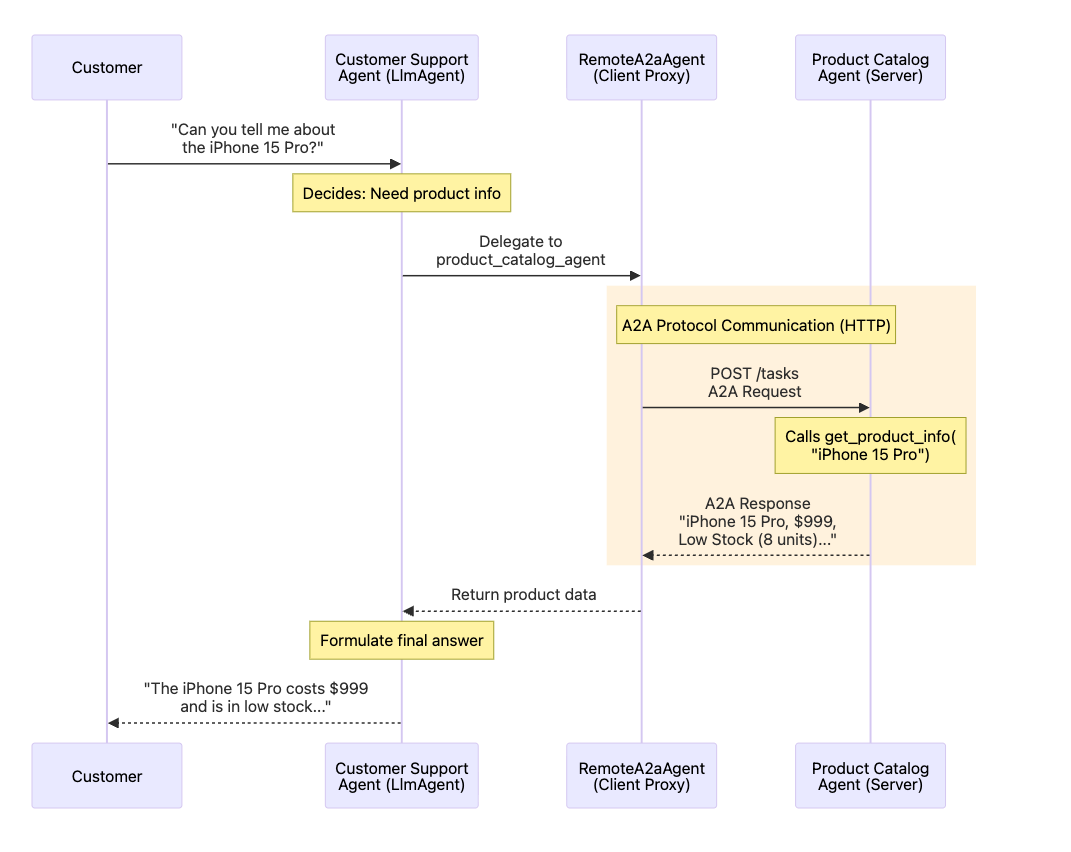

**A2A Protocol Communication**:

Behind the scenes, here's what happens at the protocol level:
- `RemoteA2aAgent` sends HTTP POST requests to the `/tasks` endpoint on `http://localhost:8001`
- Request and response data follow the A2A Protocol Specification
- Data is exchanged in standardized JSON format
- The protocol ensures any A2A-compatible agent (regardless of language/framework) can communicate

This standardization is what makes cross-organization, cross-language agent communication possible!

---

**What happened**:
1. **Customer** asked about the iPhone 15 Pro
2. **Customer Support Agent** (LlmAgent) received the question and decided it needs product information
3. **Support Agent** delegated to the `product_catalog_agent` sub-agent
4. **RemoteA2aAgent** (client-side proxy) translated this into an A2A protocol request
5. The A2A request was sent over HTTP to `http://localhost:8001` (highlighted in yellow)
6. **Product Catalog Agent** (server) received the request and called `get_product_info("iPhone 15 Pro")`
7. **Product Catalog Agent** returned the product information via A2A response
8. **RemoteA2aAgent** received the response and passed it back to the Support Agent
9. **Support Agent** formulated a final answer with the product details
10. **Customer** received the complete, helpful response

**Key Benefits Demonstrated**
1. **Transparency**: Support Agent doesn't "know" Product Catalog Agent is remote
2. **Standard Protocol**: Uses A2A standard - any A2A-compatible agent works\
3. **Easy Integration**: Just one line: `sub_agents=[remote_product_catalog_agent]`
4. **Separation of Concerns**: Product data lives in Catalog Agent (vendor), support logic in Support Agent (your company)

---

**Real-World Applications**

This pattern enables:
- Microservices: Each agent is an independent service
- Third-party Integration: Consume agents from external vendors (e.g., product catalogs, payment processors)
- Cross-language: Product Catalog Agent could be Java, Support Agent Python
- Specialized Teams: Vendor maintains catalog, your team maintains support agent
- Cross-Organization: Vendor hosts catalog on their infrastructure, you integrate via A2A

# Resources

1. <a href="https://a2a-protocol.org/latest/">A2A Protocol</a>
2. <a href="https://adk.dev/a2a/quickstart-exposing/">Exposing agents with A2A</a>
3. <a href="https://adk.dev/a2a/quickstart-consuming/">Consuming a Remote Agent via A2A</a>
4. <a href="https://a2a-protocol.org/latest/specification/">A2A protocol Specification</a>
5. <a href="https://adk.dev/deploy/cloud-run/">Deploying agents on Cloud Run</a>
6. <a href=""></a>
7. <a href=""></a>
8. <a href=""></a>